# Setup

## Runtime Estimatation

## Imports

In [1]:
# ops
from time import time
# warnings
import warnings
# visualization
# deep learning libs
import torch
from PDD_training import train_and_store
from PDD_helpers import get_train_val_test_datasets, plot_training, show_lb,plot_cm, show_predictions
from PDD_helpers import ViTConfig as VTC
from PDD_data_mgmt import CropDiseaseDataset,PreBatchedDataset 
from torch.utils.data import DataLoader
# data mgmt
from dataclasses import asdict, dataclass

In [2]:
start_run_time = time()

## Random Seed

In [3]:
torch.manual_seed(42)

## CUDA

In [4]:
# warn user if CPU
use_cuda = True if torch.cuda.is_available() else False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.get_device_name(0)) if use_cuda else warnings.warn('We are using CPU.')
torch.cuda.set_device(0)  # force correct GPU
device = torch.device("cuda:0")

NVIDIA GeForce RTX 3080 Ti Laptop GPU


# Hyperparameter Storage Class

In [5]:
@dataclass
class BestViTConfig:
    batch_alias: str 
    # architecture
    patch_size: int        = 16
    embedding_dim: int     = 512
    depth: int             = 6
    heads: int             = 12
    attn_head_dim: int     = 64
    ffn_inner_dim: int     = 1024
    head_hidden_dim: int   = 256
    # regularization
    emb_dropout: float     = 0.0
    attn_dropout: float    = 0.1
    ffn_dropout: float     = 0.1
    head_dropout: float    = 0.1
    decay: float           = 1e-6
    # optimization
    opt: str               = "adamw"
    lr: float              = 1e-4
    scheduler: bool        = True
    train_aug: str         = "flipmix"
    loss: str              = "focal"
    # training
    epochs: int            = 75
    n_runs: int            = 1

# Load

## Load Images to Dataset

In [6]:
dataset = CropDiseaseDataset(
    root = "./FieldPlant_augmented_tensor",
)
num_classes = len(dataset.class_names)

# Train-Val-Test Split 

In [7]:
train_dataset,val_dataset,test_dataset = get_train_val_test_datasets(dataset, train_p = 0.8,)

## Data Loaders

In [8]:
batch_size = 256
test_loader = DataLoader(test_dataset,
                                   batch_size=batch_size, 
                                   num_workers=6,
                                   shuffle= False)

In [9]:

train_prebatch = PreBatchedDataset(train_dataset,
                                   batch_size=batch_size, 
                                   shuffle= True)
val_prebatch = PreBatchedDataset(val_dataset,
                                   batch_size=batch_size, 
                                   shuffle= False)


## Results Logging

In [10]:
training_log = []

# Experiments

## Zero DO Flip vs Flipmix

In [12]:
if __name__ == '__main__':
    for train_aug in ["flip","flipmix"]:
        config = BestViTConfig(batch_alias="0.1_DO_Aug",
                                patch_size= 28,
                                train_aug=train_aug,
                                attn_dropout = 0.1,
                                ffn_dropout =0.1,
                                head_dropout= 0.1,
                                n_runs=3)
        train_and_store(**asdict(config),
                        train_loader=train_prebatch,
                        val_loader=val_prebatch, 
                        training_log=training_log,
                        save_model=True
                        )


[0.1_DO_Aug] run 1/3 — A=12x64 T=6x1024 H=256 patch=28 aug=flip do_e,a,t,h=0.0,0.1,0.1,0.1 opt=adamw lr=0.0001 wd=1e-06 sched=cosine


Training Epoch:  65%|██████▌   | 49/75 [08:20<04:25, 10.21s/it]


Early stopping triggered at epoch 50

[0.1_DO_Aug] run 2/3 — A=12x64 T=6x1024 H=256 patch=28 aug=flip do_e,a,t,h=0.0,0.1,0.1,0.1 opt=adamw lr=0.0001 wd=1e-06 sched=cosine


Training Epoch:  65%|██████▌   | 49/75 [08:46<04:39, 10.75s/it]


Early stopping triggered at epoch 50

[0.1_DO_Aug] run 3/3 — A=12x64 T=6x1024 H=256 patch=28 aug=flip do_e,a,t,h=0.0,0.1,0.1,0.1 opt=adamw lr=0.0001 wd=1e-06 sched=cosine


...


[0.1_DO_Aug] run 2/3 — A=12x64 T=6x1024 H=256 patch=28 aug=flipmix do_e,a,t,h=0.0,0.1,0.1,0.1 opt=adamw lr=0.0001 wd=1e-06 sched=cosine


Training Epoch:  88%|████████▊ | 66/75 [12:29<01:42, 11.36s/it]


Early stopping triggered at epoch 67

[0.1_DO_Aug] run 3/3 — A=12x64 T=6x1024 H=256 patch=28 aug=flipmix do_e,a,t,h=0.0,0.1,0.1,0.1 opt=adamw lr=0.0001 wd=1e-06 sched=cosine


Training Epoch: 100%|██████████| 75/75 [13:58<00:00, 11.18s/it]



  [0.1_DO_Aug] A=12x64 T=6x1024 H=256 patch=28 aug=flipmix do_e,a,t,h=0.0,0.1,0.1,0.1 opt=adamw lr=0.0001 wd=1e-06 sched=cosine
  val F1 across 3 runs: ['0.8968', '0.9031', '0.9087']  F1 mean=0.9029 Acc mean=0.9044 13m59s
model saved to ./models/A=12x64 T=6x1024 H=256 patch=28 aug=flipmix do_e,a,t,h=0.0,0.1,0.1,0.1 opt=adamw lr=0.0001 wd=1e-06 sched=cosine_best.pth


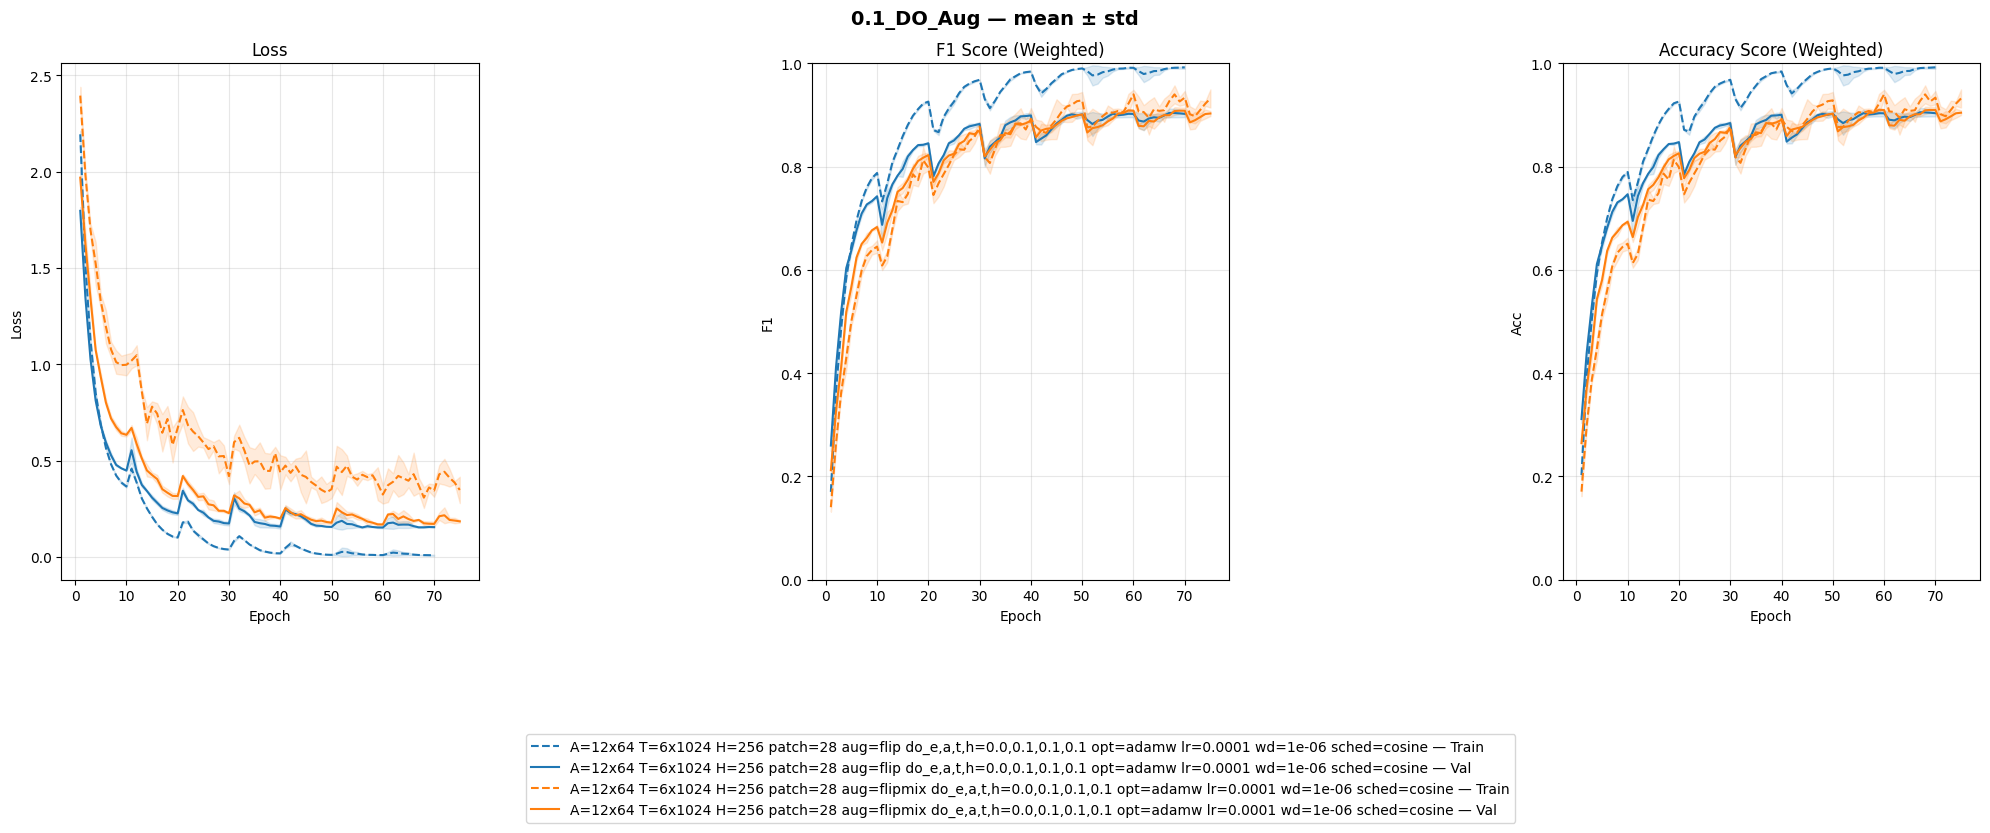

In [18]:
plot_training("0.1_DO_Aug", training_log)

In [17]:
show_lb(training_log)

,config,runs,f1 (mean),acc (mean),loss (mean),epochs (mean),training time (mean)
1,"A=12x64 T=6x1024 H=256 patch=28 aug=flipmix do_e,a,t,h=0.0,0.1,0.1,0.1 opt=adamw lr=0.0001 wd=1e-06 sched=cosine",3,0.9029,0.9044,0.1850,72.3,808.2
2,"A=12x64 T=6x1024 H=256 patch=28 aug=flip do_e,a,t,h=0.0,0.1,0.1,0.1 opt=adamw lr=0.0001 wd=1e-06 sched=cosine",3,0.9022,0.9035,0.1549,56.7,596.2


# Inspect Predictions

In [13]:
from PDD_ViT import VisionTransformer
state_dict_path = "./models/A=12x64 T=6x1024 H=256 patch=28 aug=flipmix do_e,a,t,h=0.0,0.1,0.1,0.1 opt=adamw lr=0.0001 wd=1e-06 sched=cosine_best.pth"
best_model = VisionTransformer(patch_size= 28, embedding_dim= 512, depth= 6, heads= 12, attn_head_dim= 64, ffn_inner_dim= 1024, head_hidden_dim= 256, emb_dropout= 0.0, attn_dropout= 0.1, ffn_dropout= 0.1, head_dropout= 0.1)
state_dict = torch.load(state_dict_path)
best_model.load_state_dict(state_dict)
best_model = best_model.to("cuda")

ACC: 0.8984 
 F1-W] 0.8953


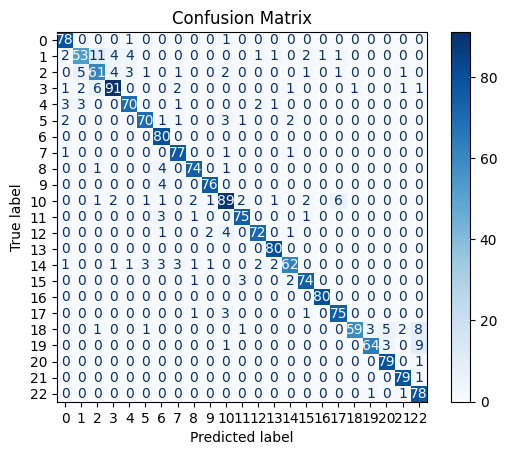

In [14]:
plot_cm(best_model,test_loader)

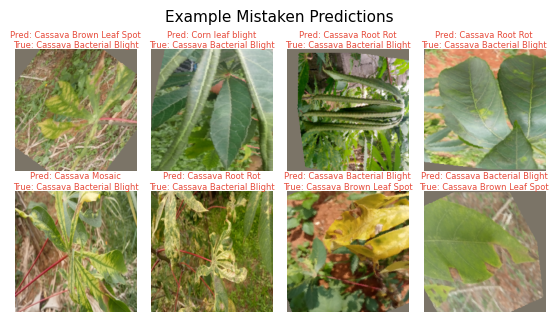

In [15]:
show_predictions(best_model, test_dataset.dataset, n=8, cols=4)

### Runtime

In [16]:
print(f"Total runtime is {(time() - start_run_time)/60} minutes.")

Total runtime is 72.13007009029388 minutes.
